Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Carga imagen desde archivo con OpenCV y convierte a RGB

(512, 512, 3)


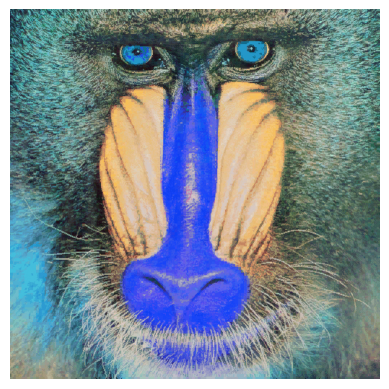

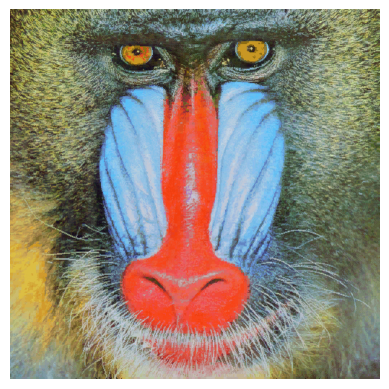

In [30]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

#Si hay lectura correcta
if img is not None:
    #Muestra dimensiones
    print(img.shape)
    #Muestra la imagen original con matplotlib
    plt.figure()
    #Elimina etiquetas de los ejes que muestra matplotlib
    plt.axis("off")
    plt.imshow(img) 
    plt.show()

    #Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Muestra la imagen tras convertir a RGB
    #Eliminamos etiquetas de los ejes
    plt.figure()
    plt.axis("off")
    plt.imshow(img_rgb) 
    plt.show()
else: 
    print('Imagen no encontrada')

Escribe un texto en una posición de la imagen

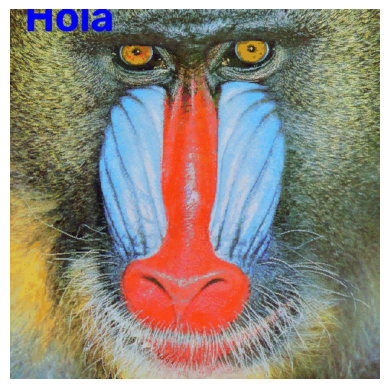

In [3]:
# Define tipografías (Bastante limitadas en OpenCV)
font = cv2.FONT_HERSHEY_SIMPLEX
    
# Define parámetros del texto
position=(20,30)
font_scale=2.0
color=(0, 0, 255)
thickness=2
# Añade texto a la imagen
cv2.putText(img_rgb, "Hola", position, font, font_scale, color, thickness)

plt.figure()
plt.axis("off")
plt.imshow(img_rgb) 
plt.show()

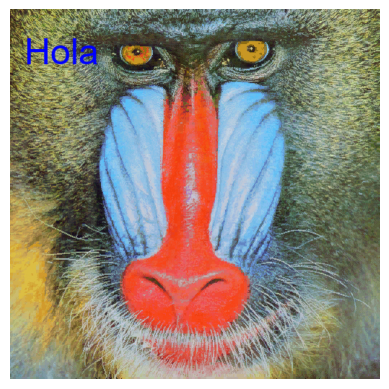

In [3]:
#Para más tipografías, usar PIL como alternativa
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Conversión de numpy array a PIL Image (tener presente que debe ser RGB, por ello la conversión previa)
pil_image = Image.fromarray(img_rgb) 
#Crea objeto para dibujar
draw = ImageDraw.Draw(pil_image)

# Carga tipografía (puede haber errores) y define parámetros
position=(20,30)
font_size=50.0
color=(0, 0, 255)
#Tipografías en Windows
font = ImageFont.truetype("arial.ttf", font_size)
#font = ImageFont.truetype("times.ttf", font_size)
#font = ImageFont.truetype("verdana.ttf", font_size)
#font = ImageFont.truetype("tahoma.ttf", font_size)

# Añade texto a la imagen
draw.text(position, "Hola", fill=color, font=font)

# Convierte resultado a numpy array para matplotlib
final_img_rgb = np.array(pil_image)

plt.figure()
plt.axis("off")
plt.imshow(final_img_rgb) 
plt.show()

Convierte la imagen a grises para procesamiento posterior

(512, 512)


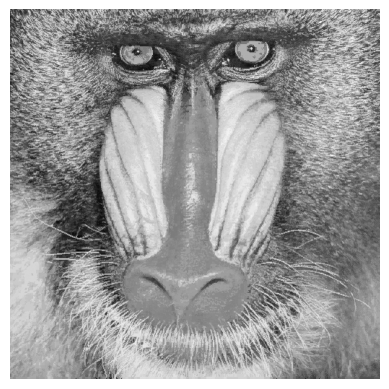

In [5]:
#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)
#Muestra, indicando el mapa de color de grises con matplotlib
plt.figure()
#Eliminamos etiquetas de los ejes
plt.axis("off")
#Muestra la imegen en grises
plt.imshow(gris, cmap='gray') 
plt.show()


Canny, detector de contornos multietapa. Descrito en mayor detalle en las sesiones de teoría (tema 4)

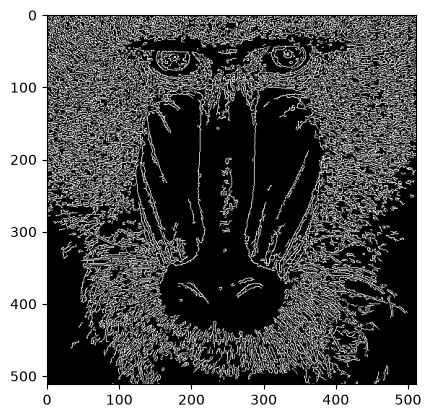

In [6]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()


Cuenta el número de píxeles no nulos por columna y visualiza el vector resultante

(0.0, 512.0)

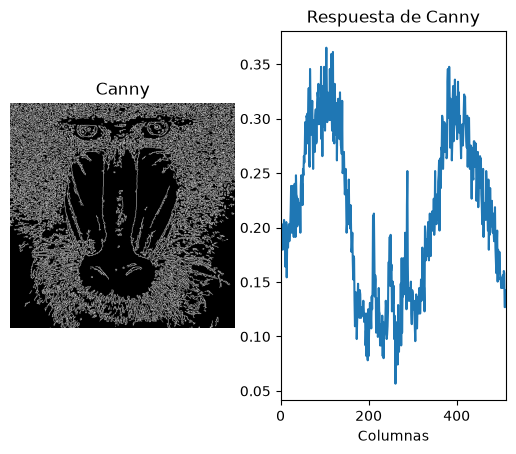

In [7]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

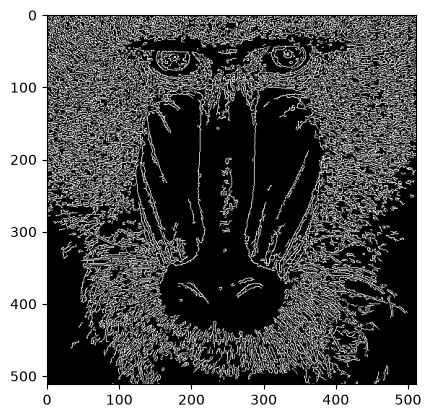

In [6]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()


7 [6, 12, 15, 20, 21, 88, 100]


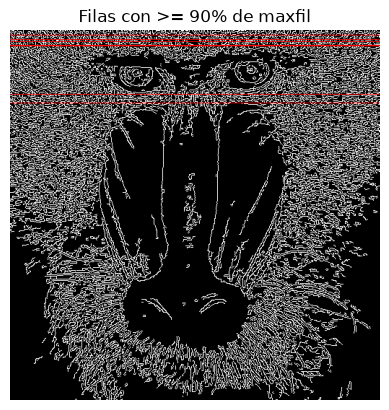

In [ ]:

#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO DE PÍXELES MÁXIMOS DE LA SUMA DE PÍXELES POR FILA
maxfil = np.max(row_counts) / 255

#Normaliza en base al número de columnas, segundo valor devuelto por shape (longitud de cada fila), y al valor máximo del píxel (255)
#El resultado será la proporción de píxeles blancos por fila (entre 0 y 1)
rows = row_counts[:] / (255 * canny.shape[1])

#REALIZAMOS UN BUCLE GUARDANDO EN UN ARRAY LOS VALORES DE ROW COUNTS QUE CUMPLAN LA CONDICIÓN REQUERIDA
condition_values = []
for i, value in enumerate(row_counts):
    if value / 255 >= (0.9 * maxfil):
        condition_values.append(i)

print(len(condition_values), condition_values) #MUESTRA EL NÚMERO DE FILAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES

canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)

#DIBUJA LÍNEAS ROJAS EN LAS FILAS QUE CUMPLEN LA CONDICIÓN
for f in condition_values:
    cv2.line(canny_color, (0, f), (canny.shape[1] - 1, f), (0, 0, 255), 1)

#MUESTRA EL RESULTADO FINAL CON LAS FILAS QUE CUMPLEN LA CONDICIÓN
plt.figure()
plt.axis("off")
plt.title("Filas con >= 90% de maxfil")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))
plt.show()







Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

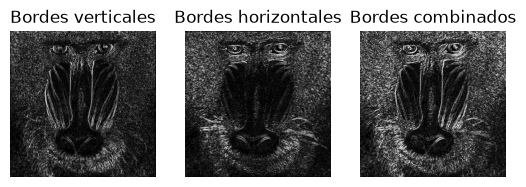

In [32]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Muestra ambos resultados
plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')
#Verticales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')
#Horizontales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


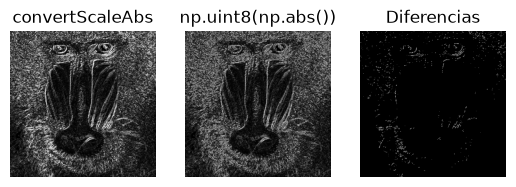

In [33]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

Umbralizado de una imagen

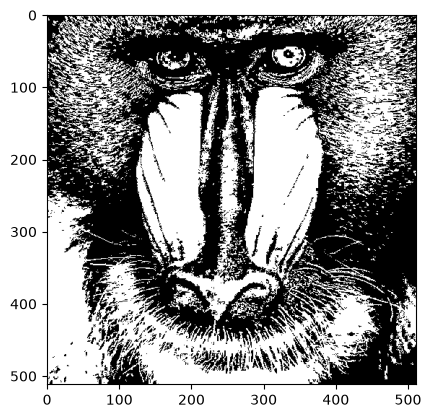

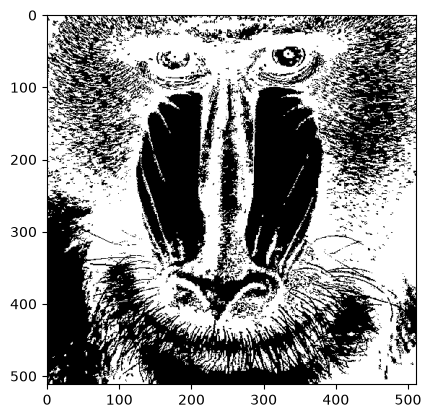

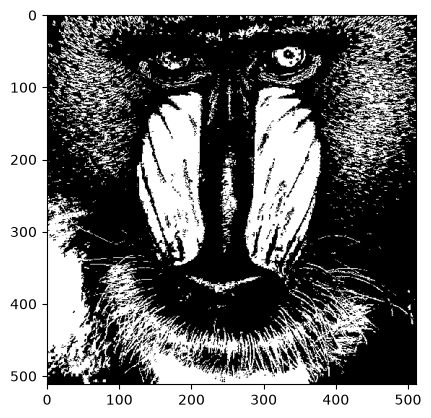

In [10]:
#Define valor umbral
valorUmbral = 130 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY_INV)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(gris, 150, 200)
#Muestra resultado
plt.imshow(imagenEnRango, cmap='gray')
plt.show()

El histograma de una imagen aporta información sobre el valor de umbral a elegir para ciertas situaciones

(0.0, 256.0)

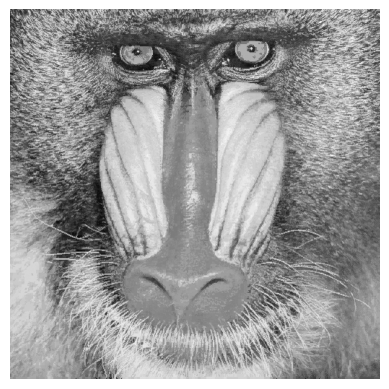

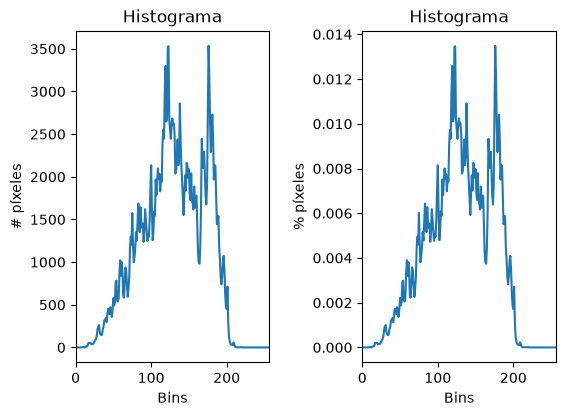

In [11]:
#Cálculo del histograma de una imagen en escala de grises
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

plt.figure()
plt.axis("off")
plt.imshow(gris, cmap='gray')

# Histograma sin normalizar
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

#Normaliza el histograma en base al número de píxeles y lo muestra
hist /= hist.sum()

plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("% píxeles")
plt.tight_layout(pad=3.0) #separación entre plots
plt.plot(hist)
plt.xlim([0, 256])

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

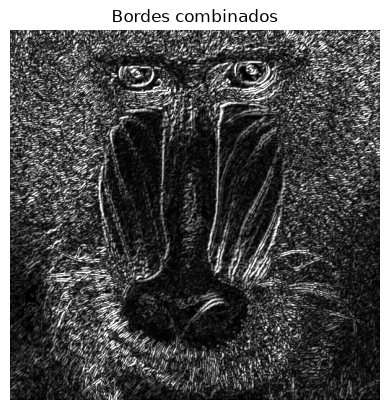

In [ ]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

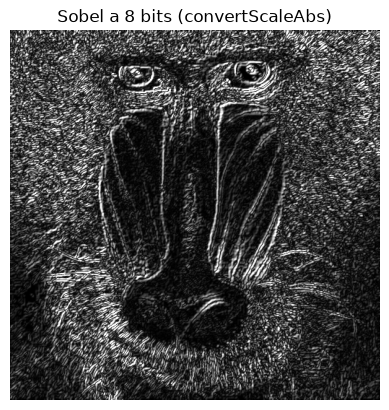

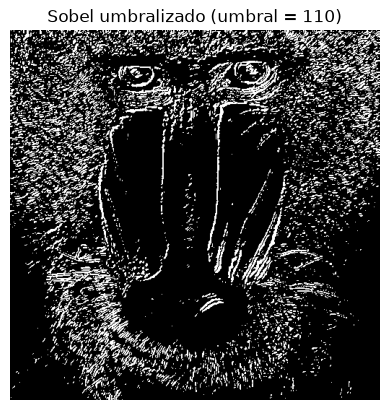

4 [3, 8, 82, 83]
5 [104, 105, 127, 287, 288]


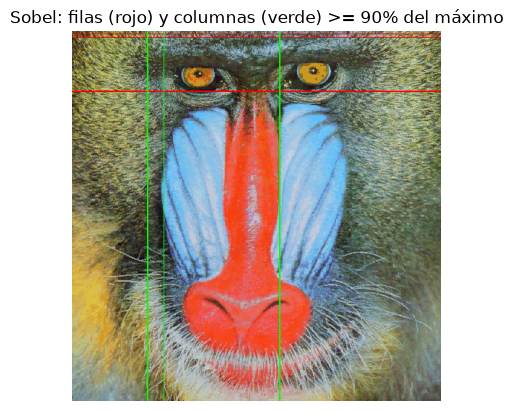

In [52]:
sobel8 = cv2.convertScaleAbs(sobel)
plt.figure()
plt.axis("off")
plt.title('Sobel a 8 bits (convertScaleAbs)')
plt.imshow(sobel8, cmap='gray')
plt.show()

#Define valor umbral
valorUmbral = 110 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

plt.figure()
plt.axis("off")
plt.title(f'Sobel umbralizado (umbral = {valorUmbral})')
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#CONTAMOS POR FILAS Y COLUMNAS
#Cuenta el número de píxeles blancos (255) por fila y columna
#Suma los valores de los pixeles por fila y columna
row_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO DE PÍXELES MÁXIMOS DE LA SUMA DE PÍXELES POR FILA Y COLUMNA
maxrow = np.max(row_counts) / 255
maxcol = np.max(col_counts) / 255

#REALIZAMOS UN BUCLE GUARDANDO EN UN ARRAY LOS VALORES DE ROW COUNTS QUE CUMPLAN LA CONDICIÓN REQUERIDA
row_values = []
for i, value in enumerate(row_counts):
    if value / 255 >= (0.9 * maxrow):
        row_values.append(i)

col_values = []
for i, value in enumerate(col_counts[0]):
    if value / 255 >= (0.9 * maxcol):
        col_values.append(i)


print(len(row_values), row_values) #MUESTRA EL NÚMERO DE FILAS Y COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES
print(len(col_values), col_values) #MUESTRA EL NÚMERO DE FILAS Y COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES



#COPIA LA IMAGEN ORIGINAL PARA DIBUJAR SOBRE ELLA
mandril_lines = img.copy()

#DIBUJA UNA LÍNEA HORIZONTAL ROJA EN CADA FILA QUE CUMPLE LA CONDICIÓN
for f in row_values:
    cv2.line(mandril_lines, (0, f), (mandril_lines.shape[1] - 1, f), (0, 0, 255), 1)

#DIBUJA UNA LÍNEA VERTICAL VERDE EN CADA COLUMNA QUE CUMPLE LA CONDICIÓN
for c in col_values:
    cv2.line(mandril_lines, (c, 0), (c, mandril_lines.shape[0] - 1), (0, 255, 0), 1)

#MUESTRA LA IMAGEN RESULTANTE (CONVERTIDA A RGB PARA QUE MATPLOTLIB MUESTRE BIEN LOS COLORES)
plt.figure()
plt.axis("off")
plt.title("Sobel: filas (rojo) y columnas (verde) >= 90% del máximo")
plt.imshow(cv2.cvtColor(mandril_lines, cv2.COLOR_BGR2RGB))
plt.show()


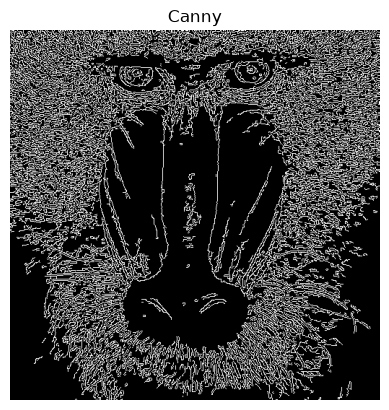

Canny maxrow: 220.0 | Filas: 7 [6, 12, 15, 20, 21, 88, 100]
Canny maxcol: 187.0 | Columnas: 19 [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]


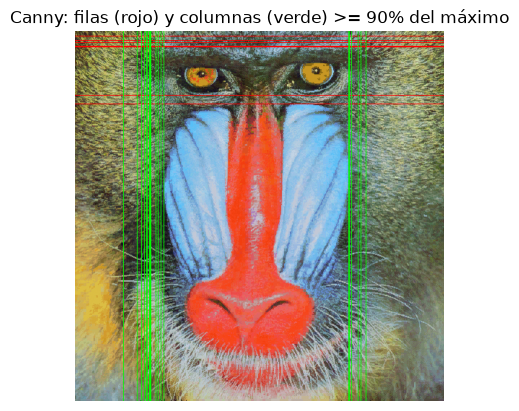

In [ ]:
#CANNY YA ES BINARIA (0 O 255), ASÍ QUE NO HACE FALTA CONVERTIR NI UMBRALIZAR
plt.figure()
plt.axis("off")
plt.title('Canny')
plt.imshow(canny, cmap='gray')
plt.show()

#CONTAMOS POR FILAS Y COLUMNAS
row_counts_canny = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts_canny = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#OBTENEMOS EL NÚMERO MÁXIMO DE PÍXELES BLANCOS POR FILA Y POR COLUMNA
maxrow_canny = np.max(row_counts_canny) / 255
maxcol_canny = np.max(col_counts_canny) / 255

#GUARDAMOS LAS POSICIONES DE LAS FILAS QUE CUMPLEN LA CONDICIÓN
row_values_canny = []
for i, value in enumerate(row_counts_canny):
    if value / 255 >= (0.9 * maxrow_canny):
        row_values_canny.append(i)

#GUARDAMOS LAS POSICIONES DE LAS COLUMNAS QUE CUMPLEN LA CONDICIÓN
col_values_canny = []
for i, value in enumerate(col_counts_canny[0]):
    if value / 255 >= (0.9 * maxcol_canny):
        col_values_canny.append(i)

#MUESTRA EL MÁXIMO, EL NÚMERO DE FILAS/COLUMNAS QUE CUMPLEN LA CONDICIÓN Y SUS ÍNDICES
print("Canny maxrow:", maxrow_canny, "| Filas:", len(row_values_canny), row_values_canny)
print("Canny maxcol:", maxcol_canny, "| Columnas:", len(col_values_canny), col_values_canny)

#COPIA NUEVA DEL MANDRIL PARA NO MEZCLAR CON LAS LÍNEAS DE SOBEL
mandril_lines_canny = img.copy()

#DIBUJA UNA LÍNEA HORIZONTAL ROJA EN CADA FILA QUE CUMPLE LA CONDICIÓN
for f in row_values_canny:
    cv2.line(mandril_lines_canny, (0, f), (mandril_lines_canny.shape[1] - 1, f), (0, 0, 255), 1)

#DIBUJA UNA LÍNEA VERTICAL VERDE EN CADA COLUMNA QUE CUMPLE LA CONDICIÓN
for c in col_values_canny:
    cv2.line(mandril_lines_canny, (c, 0), (c, mandril_lines_canny.shape[0] - 1), (0, 255, 0), 1)

#MUESTRA LA IMAGEN RESULTANTE
plt.figure()
plt.axis("off")
plt.title("Canny: filas (rojo) y columnas (verde) >= 90% del máximo")
plt.imshow(cv2.cvtColor(mandril_lines_canny, cv2.COLOR_BGR2RGB))
plt.show()

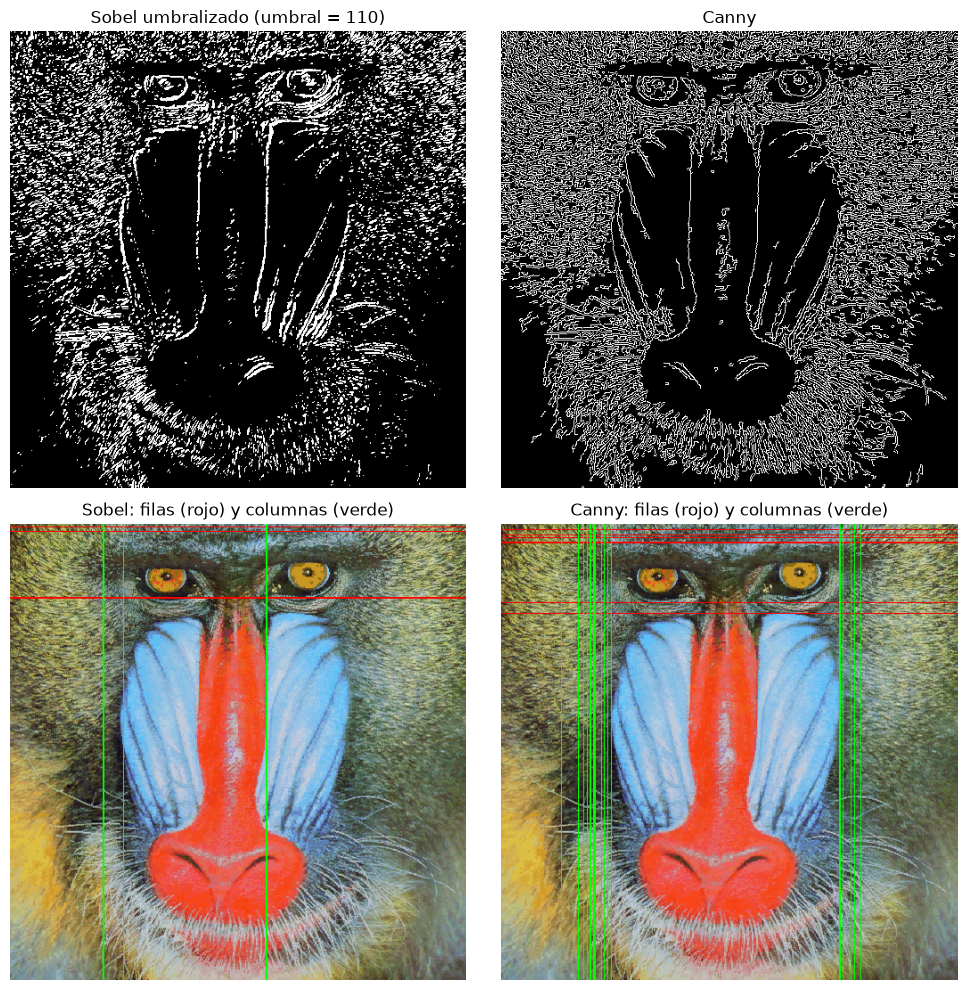

In [54]:
plt.figure(figsize=(10, 10))

#IMAGEN BINARIA DE SOBEL UMBRALIZADO
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title(f'Sobel umbralizado (umbral = {valorUmbral})')
plt.imshow(imagenUmbralizada, cmap='gray')

#IMAGEN BINARIA DE CANNY
plt.subplot(2, 2, 2)
plt.axis("off")
plt.title('Canny')
plt.imshow(canny, cmap='gray')

#MANDRIL CON LAS FILAS Y COLUMNAS SELECCIONADAS POR SOBEL
plt.subplot(2, 2, 3)
plt.axis("off")
plt.title('Sobel: filas (rojo) y columnas (verde)')
plt.imshow(cv2.cvtColor(mandril_lines, cv2.COLOR_BGR2RGB))

#MANDRIL CON LAS FILAS Y COLUMNAS SELECCIONADAS POR CANNY
plt.subplot(2, 2, 4)
plt.axis("off")
plt.title('Canny: filas (rojo) y columnas (verde)')
plt.imshow(cv2.cvtColor(mandril_lines_canny, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()

Ambos métodos coinciden en las filas destacadas (frente y zona de los ojos), que son las que atraviesan más pelo. Sin embargo, Canny es considerablemente más preciso: gracias a la supresión de no máximos, localiza cada borde en su posición exacta con un grosor de un solo píxel, y la histéresis con doble umbral le permite conservar bordes débiles conectados a otros fuertes y descartar el ruido aislado, por lo que los contornos aparecen finos y continuos. Esto hace que los bordes se repartan uniformemente por la textura y que muchas filas y columnas se acerquen al máximo, apareciendo agrupadas, sobre todo en el pelo de ambas mejillas. Sobel umbralizado, en cambio, genera bordes más gruesos y fragmentados, ya que marca toda la zona donde hay variación de intensidad y no solo el punto central del borde, y su conteo está dominado por unos pocos bordes de alto contraste (como el lateral derecho de la nariz), por lo que selecciona menos filas y columnas, y en parte distintas. Además, el resultado de Sobel depende fuertemente del único umbral elegido, mientras que Canny ofrece un resultado más estable.

Diferencia de imágenes

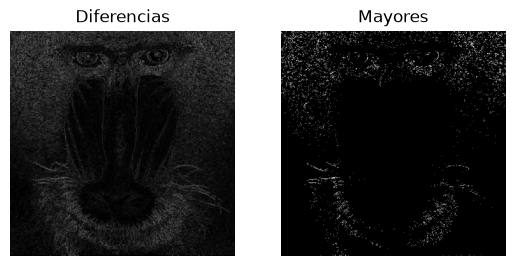

In [55]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


Webcam y sustracción de fotogramas

In [56]:
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)        
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Webcam y sustracción de modelo del fondo

In [62]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem=cv2.flip(frame, 1)
        
        #Con un segundo parámerto se puede definir máscara con zonas a actualizar
        objetos = eliminadorFondo.apply(framem)
        #objetos = eliminadorFondo.apply(framem, objetos, 0)  #No actualiza el fondo
        # Obtiene fondo
        background = eliminadorFondo.getBackgroundImage()

        # Muestra resultado
        cv2.imshow('Fotograma', objetos)
        # Muestra fondo
        cv2.imshow('Fondo', background)
  
   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
#DEMOSTRADOR: CORTINA DE PRIVACIDAD DIGITAL (REINTERPRETACIÓN DE MY LITTLE PIECE OF PRIVACY)

vid = cv2.VideoCapture(0)

#Sustracción de fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=True)

while(True):
    #Fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Efecto espejo
        framem = cv2.flip(frame, 1)

        #MASCARA: 255 = PERSONA, 127 = SOMBRA, 0 = FONDO
        objetos = eliminadorFondo.apply(framem)

        #UMBRALIZA PARA QUITAR LAS SOMBRAS: TODO LO MENOR DE 200 SE CONVIERTE EN 0, LO DEMÁS EN 255
        _, mascara = cv2.threshold(objetos, 200, 255, cv2.THRESH_BINARY)

        #CUENTA POR COLUMNAS LOS PÍXELES BLANCOS DE LA MÁSCARA
        col_counts = cv2.reduce(mascara, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

        #NÚMERO MÁXIMO DE PÍXELES EN UNA COLUMNA
        maxcol = np.max(col_counts) / 255

        #SOLO SE DIBUJA LA CORTINA SI HAY ALGUIEN (EVITA TAPAR TODO CON LA MÁSCARA VACÍA)
        if maxcol > 20:
            col_values = []
            for i, value in enumerate(col_counts[0]):
                if value / 255 >= (0.3 * maxcol):       #MANTENER VALORES ENTRE 0.3 Y 0.5 PARA QUE SEA MÁS EFICAZ
                    col_values.append(i)

            #LÍMITES DE LA CORTINA: PRIMERA Y ÚLTIMA COLUMNA QUE CUMPLEN LA CONDICIÓN
            x1 = min(col_values)
            x2 = max(col_values)

            #DIBUJA LA CORTINA: RECTÁNGULO RELLENO DE ARRIBA ABAJO
            cv2.rectangle(framem, (x1, 0), (x2, framem.shape[0] - 1), (40, 40, 40), -1)

        #Muestra resultados
        cv2.imshow('Camara', framem)
        cv2.imshow('Mascara', mascara)

    #Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break

#LIBERA LA CAMARA Y DESTRUYE LAS VENTANAS
vid.release()
cv2.destroyAllWindows()